In [1]:
from numpy import random as rd
import numpy as np

# Caminata aleatoria sobre un grafo

Suponga una secuencia de $m$ elementos, compuesta de 1s y 0s bajo la siguiente condición: Una secuencia se dice que es valida si no tiene dos 1s consecutivos. Ej:

- (1,0,1,0) es una secuencia valida
- (0, 1, 1, 0) no es una secuencia valida

Sea $X$ el numero de 1s que tiene una secuencia valida de tamaño m, el objetivo es calcular el valor esperado de $X$. Una primera aproximación para resolver el problema por simulación seria generar $n$ secuencias aleatorias sin restricción y descartar las que son invalidas. Sin embargo, a medida que $m$ aumenta, la probabilidad de generar una secuencia válida al azar $P = \left(\frac{1.618}{2}\right)^m$ tiende rápidamente a cero.

In [13]:
# Algoritmo para verificar si una secuencia es valida
def es_valida(secuencia):
    m = len(secuencia)
    for i, v in enumerate(secuencia):
        if i == 0 and v == 1 and secuencia[i + 1] == 1: return False
        if i == m - 1 and v == 1 and secuencia[i - 1] == 1: return False
        if 0 < i < m - 1 and v == 1 and (secuencia[i + 1] == 1 or secuencia[i - 1] == 1): return False
    return True

n = 10000
m = 4

conteo_validas = []

# Generacion y validacion de secuencias aleatorias
for i in range(n):
    y = rd.choice([0, 1], m)
    if es_valida(y):
        conteo_validas.append(y.sum())

# Promedio del numero de 1s sobre las secuencias validas
promedio_esperado = np.mean(conteo_validas)
print(f"Valor esperado: {promedio_esperado}")

# Ratio de aceptacion
ratio = len(conteo_validas)/n
print(f"Cadenas generadas: {n}")
print(f"Cadenas aceptadas: {len(conteo_validas)}")
print(f"Ratio de aceptación: {ratio}")

Valor esperado: 1.2502520669489816
Cadenas generadas: 10000
Cadenas aceptadas: 4959
Ratio de aceptación: 0.4959


Una solucion mas eficiente consiste en seleccionar aleatoriamente una posicion $i$ de la secuencia.

- Si en la posicion $i$ hay un 1, el valor cambia a 0. La cantidad de 1s se ha reducido por lo que la secuencia sigue siendo valida.

- Si es 0, se verifica que no existan 1s en la vecindad inmediata de $i$, $i-1$, $i+1$. Si hay 1s en aquellas posiciones, se descarta y se vuelve a seleccionar otra posición aleatoriamente. Si no, el valor de la posición $i$ pasa a ser 1.

Este proceso genera una cadena de Markov donde cada estado es una secuencia valida, con probabilidad de transicion dada por $\frac{1}{m}$. Note que, para un estado $k$, sus vecinos solo difieren por un valor. 

Al estar cada estado conectado con al menos otro estado y con probabilidad de transicion uniforme, la cadena forma un grafo cuyos nodos son los estados y los pesos de las aristas estan dadas por la probabilidad.

Por lo que es posible simular una caminata aleatoria sobre el grafo para calcular numericamente el valor promedio de 1s en una secuencia. Es decir, el valor esperado de X.

![Grafo](Grafo.png)

In [3]:
# Definimos el algoritmo para generar un salto hacia una secuencia valida

def salto (y_actual):
    m = len(y_actual)
    i = rd.choice(m) # Escogemos aleatoriamente la posicion i

    y_siguiente = y_actual.copy()
    if y_actual[i] == 1: #Si la posicion i es 1, la cambiamos a 0. La cadena sigue siendo valida
        y_siguiente[i] = 0
    elif y_actual[i] == 0: #Si la posicion i es 0, verificamos las posiciones vecinas para que la cadena siga siendo valida
        if i == 0 and y_actual[i+1] == 0: #Si es la primera posicion, solo verificamos la siguiente
            y_siguiente[i] = 1
        elif i == m-1 and y_actual[i-1] == 0: #Si es la ultima posicion, solo verificamos la anterior
            y_siguiente[i] = 1
        elif y_actual[i-1] == 0 and y_actual[i+1] == 0: #Si es una posicion intermedia, verificamos ambas vecinas
            y_siguiente[i] = 1

    return y_siguiente

In [100]:
#Proponemos el estado inicial
m = 100
y_0 = np.zeros(m, dtype=int)

# Numero de iteraciones
n_iter = 10000

# Inicializamos la caminata aleatoria y el contador de 1s
cadena = np.zeros((n_iter, m))
x = np.zeros(n_iter+1)

y = y_0.copy()
x[0] = y.sum()
for i in range(n_iter):
    y = salto(y)
    x[i+1] = y.sum()
    cadena[i] = y

# Calculamos el promedio de 1s en la cadena
corte = 3000
mu = x[corte:].mean()

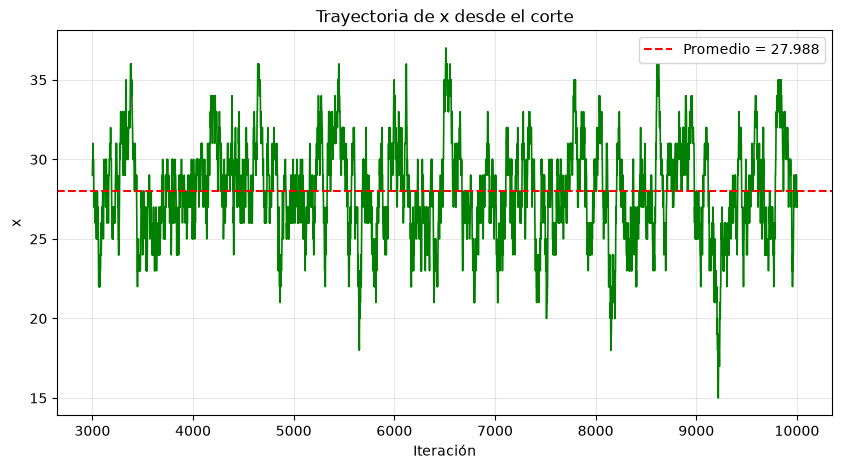

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(np.arange(corte, n_iter + 1), x[corte:], color="green", linewidth=1.2)
plt.axhline(mu, color="red", linestyle="--", label=f"Promedio = {mu:.3f}")
plt.xlabel("Iteración")
plt.ylabel("x")
plt.title("Trayectoria de x desde el corte")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()